In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np
import plotly.offline as pyo
from wordcloud import WordCloud, STOPWORDS

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [2]:
data = pd.read_csv('data.csv')

In [3]:
genre_data = pd.read_csv('data_by_genres.csv')

In [4]:
year_data = pd.read_csv('data_by_year.csv')

In [5]:
artist_data = pd.read_csv('data_by_artist.csv')

In [6]:
print("First 2 rows of data")
print(data.head(2))

First 2 rows of data
   valence  year  acousticness  \
0   0.0594  1921         0.982   
1   0.9630  1921         0.732   

                                             artists  danceability  \
0  ['Sergei Rachmaninoff', 'James Levine', 'Berli...         0.279   
1                                     ['Dennis Day']         0.819   

   duration_ms  energy  explicit                      id  instrumentalness  \
0       831667   0.211         0  4BJqT0PrAfrxzMOxytFOIz             0.878   
1       180533   0.341         0  7xPhfUan2yNtyFG0cUWkt8             0.000   

   key  liveness  loudness  mode  \
0   10     0.665   -20.096     1   
1    7     0.160   -12.441     1   

                                                name  popularity release_date  \
0  Piano Concerto No. 3 in D Minor, Op. 30: III. ...           4         1921   
1                            Clancy Lowered the Boom           5         1921   

   speechiness   tempo  
0       0.0366  80.954  
1       0.4150  60.936  


In [7]:
print("First 2 rows of genre_data")
print(genre_data.head(2))

First 2 rows of genre_data
   mode                  genres  acousticness  danceability   duration_ms  \
0     1  21st century classical      0.979333      0.162883  1.602977e+05   
1     1                   432hz      0.494780      0.299333  1.048887e+06   

     energy  instrumentalness  liveness   loudness  speechiness       tempo  \
0  0.071317          0.606834    0.3616 -31.514333     0.040567   75.336500   
1  0.450678          0.477762    0.1310 -16.854000     0.076817  120.285667   

    valence  popularity  key  
0  0.103783   27.833333    6  
1  0.221750   52.500000    5  


In [8]:
print("First 2 rows of year_data")
print(year_data.head(2))

First 2 rows of year_data
   mode  year  acousticness  danceability    duration_ms    energy  \
0     1  1921      0.886896      0.418597  260537.166667  0.231815   
1     1  1922      0.938592      0.482042  165469.746479  0.237815   

   instrumentalness  liveness   loudness  speechiness       tempo   valence  \
0          0.344878   0.20571 -17.048667     0.073662  101.531493  0.379327   
1          0.434195   0.24072 -19.275282     0.116655  100.884521  0.535549   

   popularity  key  
0    0.653333    2  
1    0.140845   10  


In [9]:
print("First 2 rows of artist_data")
print(artist_data.head(2))

First 2 rows of artist_data
   mode  count  acousticness                           artists  danceability  \
0     1      9      0.590111  "Cats" 1981 Original London Cast      0.467222   
1     1     26      0.862538         "Cats" 1983 Broadway Cast      0.441731   

     duration_ms    energy  instrumentalness  liveness  loudness  speechiness  \
0  250318.555556  0.394003          0.011400  0.290833   -14.448     0.210389   
1  287280.000000  0.406808          0.081158  0.315215   -10.690     0.176212   

        tempo   valence  popularity  key  
0  117.518111  0.389500   38.333333    5  
1  103.044154  0.268865   30.576923    5  


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170653 entries, 0 to 170652
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   valence           170653 non-null  float64
 1   year              170653 non-null  int64  
 2   acousticness      170653 non-null  float64
 3   artists           170653 non-null  object 
 4   danceability      170653 non-null  float64
 5   duration_ms       170653 non-null  int64  
 6   energy            170653 non-null  float64
 7   explicit          170653 non-null  int64  
 8   id                170653 non-null  object 
 9   instrumentalness  170653 non-null  float64
 10  key               170653 non-null  int64  
 11  liveness          170653 non-null  float64
 12  loudness          170653 non-null  float64
 13  mode              170653 non-null  int64  
 14  name              170653 non-null  object 
 15  popularity        170653 non-null  int64  
 16  release_date      17

In [11]:
genre_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2973 entries, 0 to 2972
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   mode              2973 non-null   int64  
 1   genres            2973 non-null   object 
 2   acousticness      2973 non-null   float64
 3   danceability      2973 non-null   float64
 4   duration_ms       2973 non-null   float64
 5   energy            2973 non-null   float64
 6   instrumentalness  2973 non-null   float64
 7   liveness          2973 non-null   float64
 8   loudness          2973 non-null   float64
 9   speechiness       2973 non-null   float64
 10  tempo             2973 non-null   float64
 11  valence           2973 non-null   float64
 12  popularity        2973 non-null   float64
 13  key               2973 non-null   int64  
dtypes: float64(11), int64(2), object(1)
memory usage: 325.3+ KB


In [12]:
data["decade"] = data["year"].apply(lambda x: f"{(x // 10) * 10}s")

In [13]:
print(data[["year", "decade"]].head(5))

   year decade
0  1921  1920s
1  1921  1920s
2  1921  1920s
3  1921  1920s
4  1921  1920s


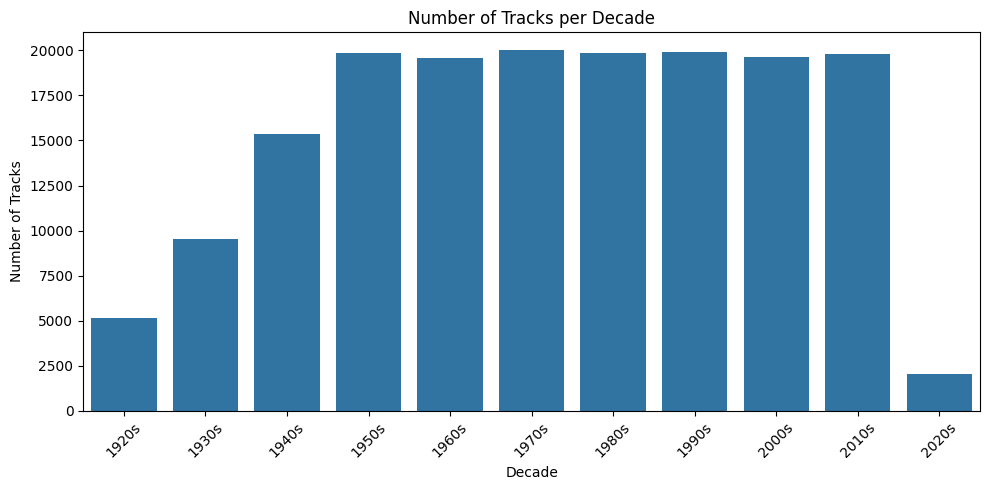

In [14]:
plt.figure(figsize=(10, 5))
sns.countplot(x="decade", data=data, order=sorted(data["decade"].unique()))
plt.title("Number of Tracks per Decade")
plt.xlabel("Decade")
plt.ylabel("Number of Tracks")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
sound_features = [
    "acousticness",
    "danceability",
    "energy",
    "instrumentalness",
    "liveness",
    "valence"
]

fig = px.line(
    year_data,
    x="year",
    y=sound_features,
    title="Trend of various sound features over decades"
)
fig.show()

In [16]:
top10_genres = genre_data.sort_values("popularity", ascending=False).head(10)

fig = px.bar(
    top10_genres,
    x="genres",
    y=["valence", "energy", "danceability", "acousticness"],
    barmode="group",
    title="Trend of various sound features over top 10 genres"
)
fig.show()

In [17]:
comment_words = " ".join(genre_data["genres"].tolist())

In [18]:
stopwords = set(STOPWORDS)

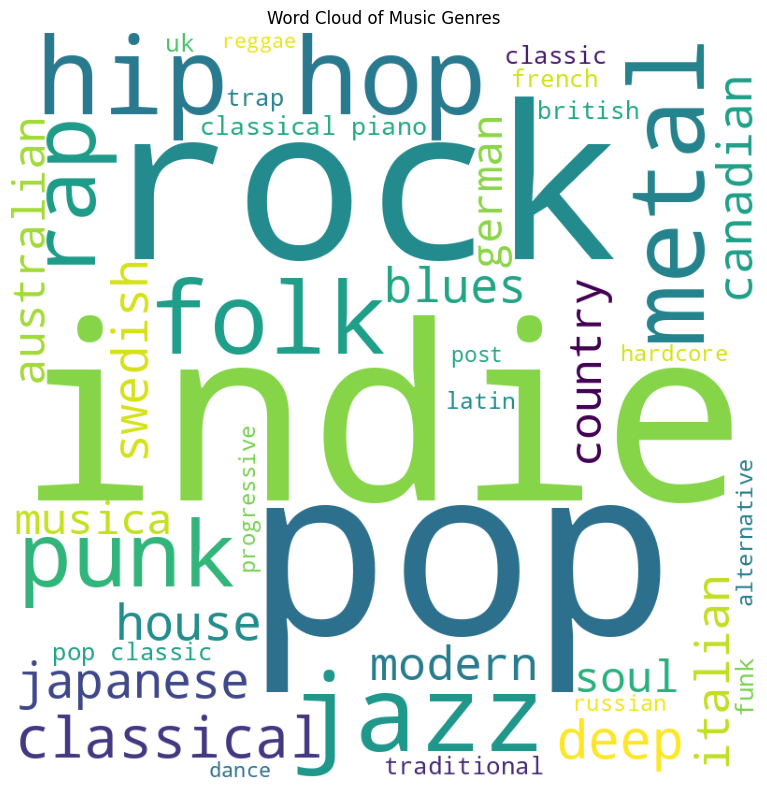

In [19]:
wordcloud = WordCloud(
    width=800,
    height=800,
    background_color="white",
    stopwords=stopwords,
    max_words=40,
    min_font_size=10
).generate(comment_words)

plt.figure(figsize=(8, 8))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud of Music Genres")
plt.tight_layout()
plt.show()

In [20]:
comment_words = " ".join(artist_data["artists"].tolist())

In [21]:
stopwords = set(STOPWORDS)

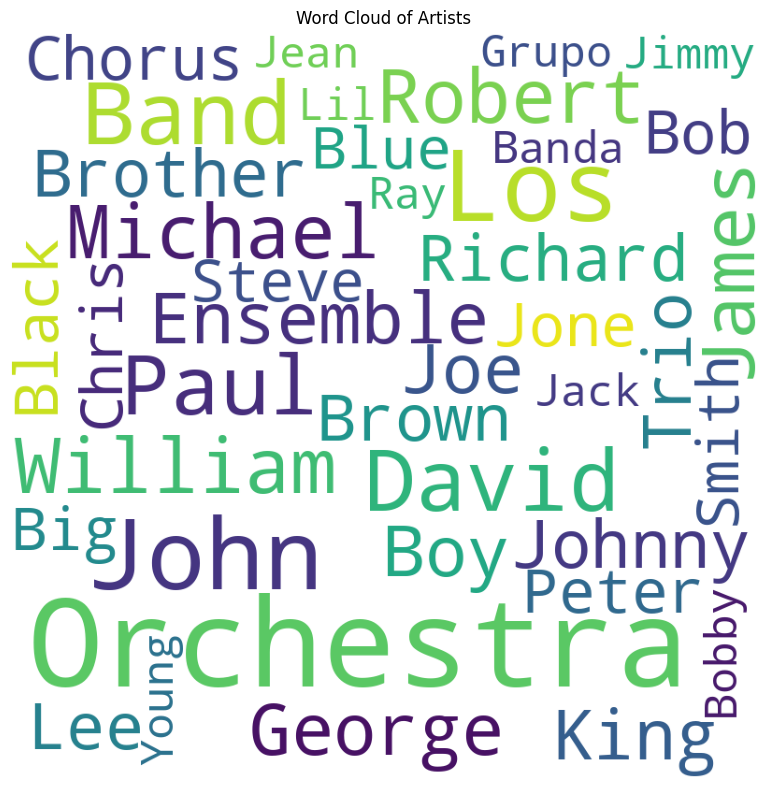

In [22]:
wordcloud = WordCloud(
    width=800,
    height=800,
    background_color="white",
    stopwords=stopwords,
    min_word_length=3,
    max_words=40,
    min_font_size=10
).generate(comment_words)

plt.figure(figsize=(8, 8))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud of Artists")
plt.tight_layout()
plt.show()

In [23]:
top10_most_song_produced_artists = artist_data.sort_values(
    "count", ascending=False
).head(10)

print("===Top 10 Artists by Number of Songs===")
print(
    top10_most_song_produced_artists[["count", "artists"]].sort_values(
        "count", ascending=False
    ).to_string(index=False)
)


===Top 10 Artists by Number of Songs===
 count           artists
  3169  Francisco Canaro
  2422  Эрнест Хемингуэй
  2136 Эрих Мария Ремарк
  1459     Frank Sinatra
  1256   Ignacio Corsini
  1200 Vladimir Horowitz
  1146  Arturo Toscanini
  1103    Billie Holiday
  1061       Johnny Cash
  1023     Elvis Presley


In [24]:
top10_popular_artists = artist_data.sort_values(
    "popularity", ascending=False
).head(10)

print("\n=== Top 10 Artists by Popularity Score ===")
print(
    top10_popular_artists[["popularity", "artists"]].sort_values(
        "popularity", ascending=False
    ).to_string(index=False)
)


=== Top 10 Artists by Popularity Score ===
 popularity         artists
       93.0     Ritt Momney
       92.0       Lele Pons
       90.0 Los Legendarios
       89.0        Jerry Di
       88.0          Emilee
       88.0     salem ilese
       88.0       Surf Mesa
       87.0             A7S
       86.0    Lenny Santos
       86.0       Master KG


**Conclusion About Data**

1/ Most songs in the dataset were released after the 1990s. This matches the growth of digital music and streaming platforms.

2/ Acousticness dropped sharply after the 1950s as electric instruments replaced acoustic ones. Energy and danceability both increased over time.

3/ Loudness has gone up every decade. Music producers make songs louder to stand out, a trend known as the loudness war.

4/ The top 10 genres have high energy and danceability, which shows that popular music tends to be upbeat.

5/ The genre word cloud is dominated by pop, rock, and hip-hop. The artist word cloud is led by classic artists with large catalogs.

6/ The most popular artists by score are recent artists, because popularity is based on recent streaming activity, not the size of the catalog.

In [25]:
print("data shape:", data.shape)
print("genre_data shape:", genre_data.shape)

data shape: (170653, 20)
genre_data shape: (2973, 14)


In [26]:
feature_cols = [
    "acousticness",
    "danceability",
    "energy",
    "instrumentalness",
    "liveness",
    "loudness",
    "speechiness",
    "tempo",
    "valence",
    "popularity"
]

In [27]:
genre_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(n_clusters=12, n_init=10, random_state=42))
])

genre_pipeline.fit(genre_data[feature_cols])

genre_data["cluster"] = genre_pipeline["kmeans"].labels_

print("=== Genre Cluster Sizes ===")
print(genre_data["cluster"].value_counts().sort_index())

=== Genre Cluster Sizes ===
cluster
0     230
1     324
2     282
3      21
4     224
5     427
6     100
7     375
8     193
9      60
10    204
11    533
Name: count, dtype: int64


In [28]:
scaler = StandardScaler()
genre_scaled = scaler.fit_transform(genre_data[feature_cols])



In [29]:
tsne = TSNE(n_components=2, random_state=42, perplexity=20)
tsne_result = tsne.fit_transform(genre_scaled)

In [30]:
genre_data["tsne_x"] = tsne_result[:, 0]
genre_data["tsne_y"] = tsne_result[:, 1]

In [31]:
genre_data["cluster"] = genre_data["cluster"].astype(str)

In [32]:
fig = px.scatter(
    genre_data,
    x="tsne_x",
    y="tsne_y",
    color="cluster",
    hover_data=["genres"],
    title="Genre Clusters visualized with t-SNE"
)
fig.show()

In [33]:
song_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(n_clusters=25, n_init=10, random_state=42))
])

song_pipeline.fit(data[feature_cols])
data["cluster"] = song_pipeline["kmeans"].labels_

print("=== Song Cluster Sizes ===")
print(data["cluster"].value_counts().sort_index())

=== Song Cluster Sizes ===
cluster
0      7807
1      5036
2      9778
3      4702
4      5519
5      5169
6      4615
7      7987
8      4193
9      8106
10     8200
11     8616
12     7253
13     3412
14     8449
15     6679
16     8552
17    11555
18     7648
19     4225
20     7559
21     7457
22     7313
23     5311
24     5512
Name: count, dtype: int64


In [34]:
song_scaled = scaler.fit_transform(data[feature_cols])

pca = PCA(n_components=2)
pca_result = pca.fit_transform(song_scaled)

var_kept = sum(pca.explained_variance_ratio_) * 100
print(f"Information kept after PCA: {var_kept:.1f}%")

data["pca_x"] = pca_result[:, 0]
data["pca_y"] = pca_result[:, 1]
data["cluster"] = data["cluster"].astype(str)

sample = data.sample(n=10000, random_state=42)

fig = px.scatter(
    sample,
    x="pca_x",
    y="pca_y",
    color="cluster",
    hover_data=["name", "artists"],   # hover → song name + artist
    title="Song Clusters visualized with PCA"
)
fig.show()

Information kept after PCA: 49.0%


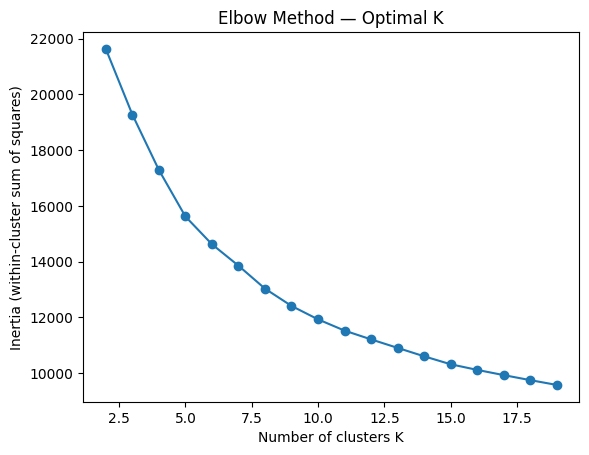

In [35]:
inertias = []
k_range = range(2, 20)

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(genre_scaled)
    inertias.append(km.inertia_)

plt.plot(k_range, inertias, marker='o')
plt.xlabel("Number of clusters K")
plt.ylabel("Inertia (within-cluster sum of squares)")
plt.title("Elbow Method — Optimal K")
plt.show()

In [36]:
score = silhouette_score(genre_scaled, genre_data["cluster"])
print(f"Silhouette Score: {score:.3f}")

Silhouette Score: 0.143
